In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("/content/OnlineRetail.csv", encoding="ISO-8859-1")

In [20]:
df.head()

df.shape

df.info()

df.isnull().sum()

df.duplicated().sum()

df.describe()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  float64       
 7   Country      397884 non-null  object        
 8   TotalPrice   397884 non-null  float64       
dtypes: datetime64[ns](1), float64(3), int64(1), object(4)
memory usage: 30.4+ MB


,Quantity,InvoiceDate,UnitPrice,CustomerID,TotalPrice
count,397884.000000,397884,397884.000000,397884.000000,397884.000000
mean,12.988238,2011-07-10 23:41:23.511023360,3.116488,15294.423453,22.397000
min,1.000000,2010-12-01 08:26:00,0.001000,12346.000000,0.001000
25%,2.000000,2011-04-07 11:12:00,1.250000,13969.000000,4.680000
50%,6.000000,2011-07-31 14:39:00,1.950000,15159.000000,11.800000
75%,12.000000,2011-10-20 14:33:00,3.750000,16795.000000,19.800000
max,80995.000000,2011-12-09 12:50:00,8142.750000,18287.000000,168469.600000
std,179.331775,NaN,22.097877,1713.141560,309.071041


In [21]:
df = df.dropna(subset=["CustomerID"])

df = df[df["Quantity"] > 0]

df = df[df["UnitPrice"] > 0]

df["InvoiceDate"] = pd.to_datetime(df["InvoiceDate"])

df["TotalPrice"] = df["Quantity"] * df["UnitPrice"]

df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


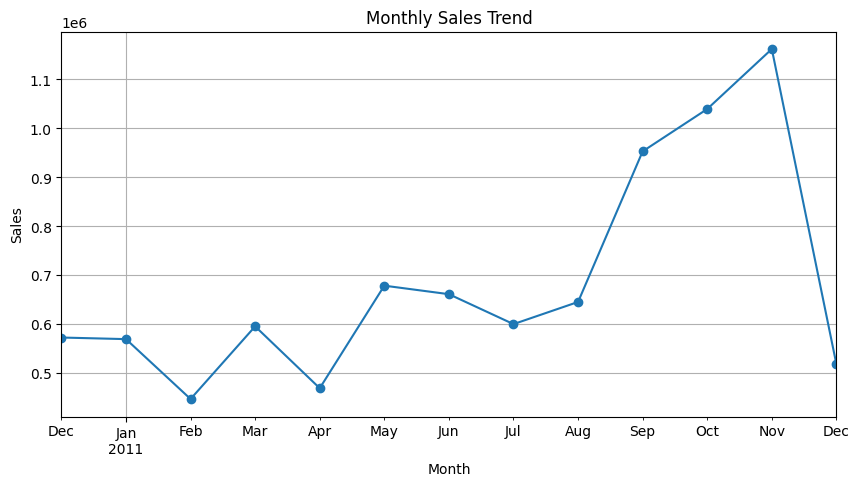

In [22]:
monthly_sales = (
    df.groupby(df["InvoiceDate"].dt.to_period("M"))["TotalPrice"]
      .sum()
)

monthly_sales.plot(figsize=(10,5), marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.grid(True)
plt.show()

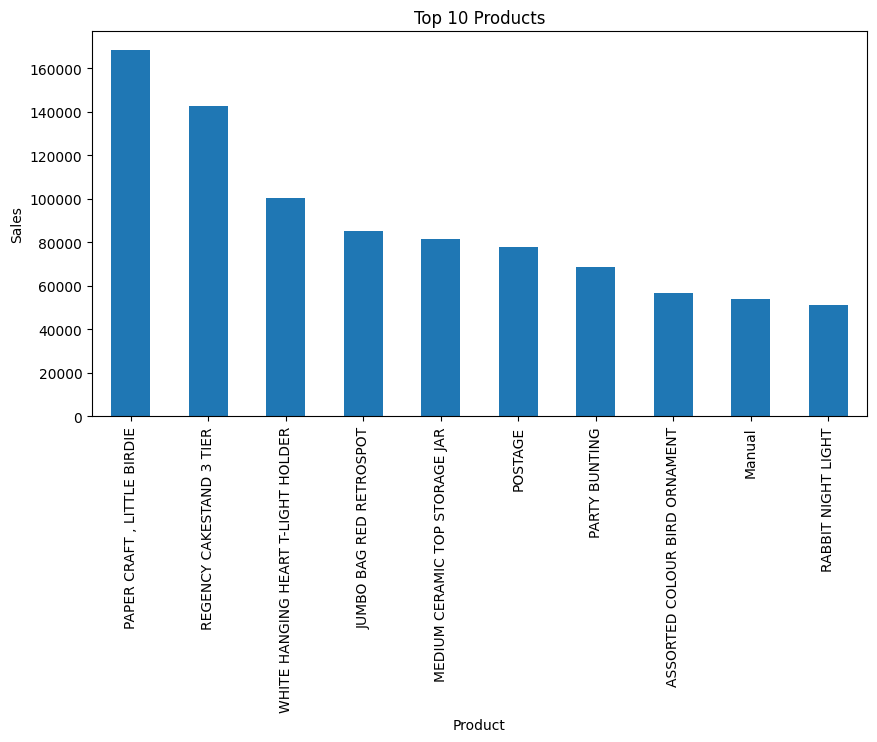

In [23]:
top_products = (
    df.groupby("Description")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_products.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Products")
plt.xlabel("Product")
plt.ylabel("Sales")
plt.show()

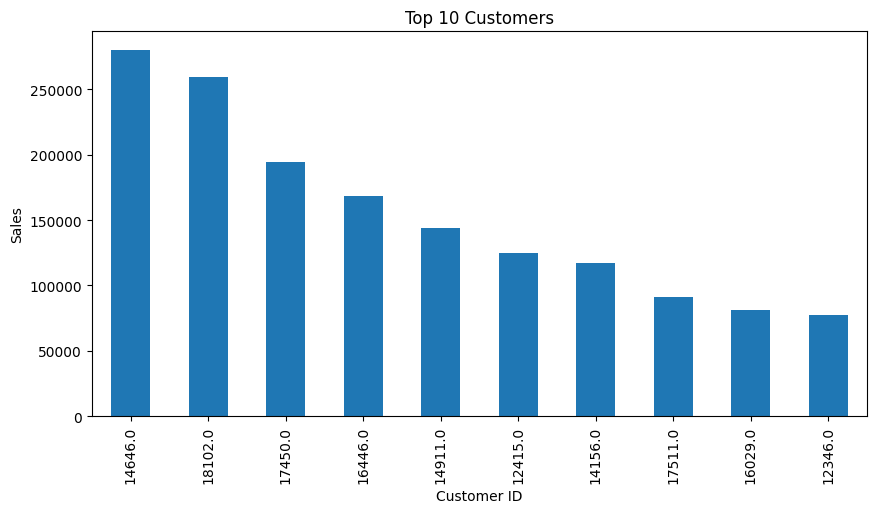

In [24]:
top_customers = (
    df.groupby("CustomerID")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

top_customers.plot(kind="bar", figsize=(10,5))
plt.title("Top 10 Customers")
plt.xlabel("Customer ID")
plt.ylabel("Sales")
plt.show()

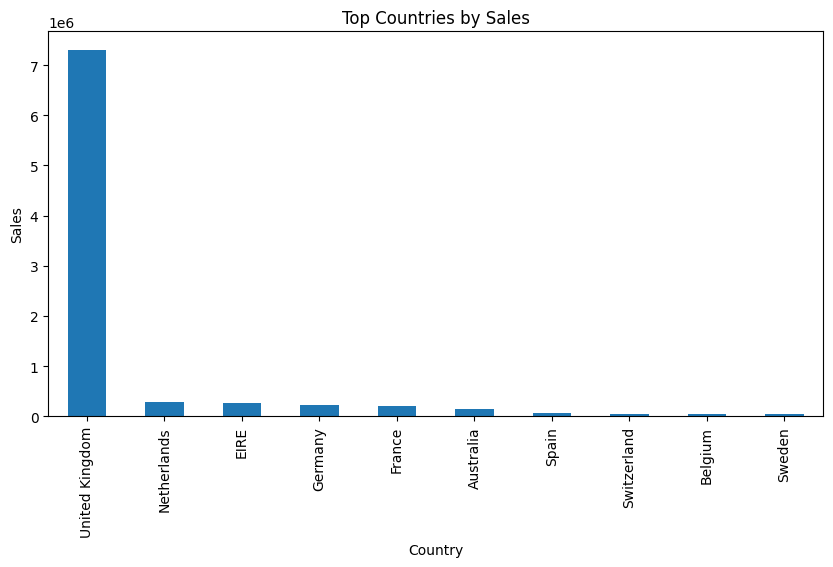

In [25]:
country_sales = (
    df.groupby("Country")["TotalPrice"]
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

country_sales.plot(kind="bar", figsize=(10,5))
plt.title("Top Countries by Sales")
plt.xlabel("Country")
plt.ylabel("Sales")
plt.show()

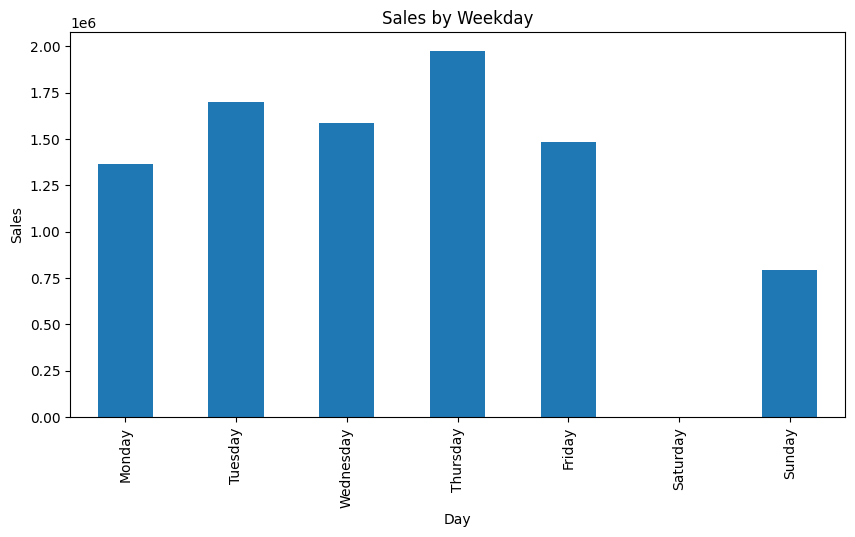

In [26]:
weekday_sales = (
    df.groupby(df["InvoiceDate"].dt.day_name())["TotalPrice"]
      .sum()
)

weekday_sales = weekday_sales.reindex([
    "Monday","Tuesday","Wednesday",
    "Thursday","Friday","Saturday","Sunday"
])

weekday_sales.plot(kind="bar", figsize=(10,5))
plt.title("Sales by Weekday")
plt.xlabel("Day")
plt.ylabel("Sales")
plt.show()

In [27]:
snapshot_date = df["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = df.groupby("CustomerID").agg({
    "InvoiceDate": lambda x: (snapshot_date - x.max()).days,
    "InvoiceNo": "count",
    "TotalPrice": "sum"
})

rfm.columns = ["Recency", "Frequency", "Monetary"]

rfm.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,326,1,77183.60
12347.0,2,182,4310.00
12348.0,75,31,1797.24
12349.0,19,73,1757.55
12350.0,310,17,334.40


In [28]:
print("Highest Revenue Country :", country_sales.idxmax())
print("Best Selling Product :", top_products.idxmax())
print("Top Customer :", top_customers.idxmax())
print("Highest Sales Weekday :", weekday_sales.idxmax())

Highest Revenue Country : United Kingdom
Best Selling Product : PAPER CRAFT , LITTLE BIRDIE
Top Customer : 14646.0
Highest Sales Weekday : Thursday
